In [1]:
import numpy as np
import time
from dataclasses import dataclass
from typing import Callable, Optional
import matplotlib.pyplot as plt

In [2]:
from simulator import generate_hierarchical
from posteriors import *
from samplers_hierarchical import *
from load_config import load_config


In [3]:
config = load_config()
test_cfg = config["testing"]
hier_cfg = config["hierarchical"]
atmo_cfg = config["atmospheric_realism"]
det_cfg = config["detector_response"]
phys_prior_cfg = config["priors"]["physics"]

rng = np.random.default_rng(int(test_cfg["seed_hierarchical_samplers"]))

print("Generating data")
ds = generate_hierarchical(
    K=int(hier_cfg["K"]),
    mu_phi=float(hier_cfg["mu_phi"]),
    sigma_phi=float(hier_cfg["sigma_phi"]),
    gamma=float(hier_cfg["gamma"]),
    eta=float(hier_cfg["eta"]),
    delta=float(hier_cfg["delta"]),
    truth_model=hier_cfg["truth_model"],
    atmo_model=atmo_cfg["model"],
    prompt_fraction=float(atmo_cfg["prompt_fraction"]),
    eta_prompt=float(config["background"].get("eta_prompt", float(hier_cfg["eta"]) * float(atmo_cfg["prompt_fraction"]))),
    infer_prompt_eta=False,
    delta_prompt=float(atmo_cfg["delta_prompt"]),
    E_knee=float(atmo_cfg["E_knee"]),
    knee_sharpness=float(atmo_cfg["knee_sharpness"]),
    prompt_prior_log_mean=float(atmo_cfg.get("prompt_prior_log_mean", np.log(1e-6))),
    prompt_prior_log_sd=float(atmo_cfg.get("prompt_prior_log_sd", 1.0)),
    prior_phi_log_mean=float(phys_prior_cfg["phi_log_mean"]),
    prior_phi_log_sd=float(phys_prior_cfg["phi_log_sd"]),
    prior_gamma_mean=float(phys_prior_cfg["gamma_mean"]),
    prior_gamma_sd=float(phys_prior_cfg["gamma_sd"]),
    prior_eta_log_mean=float(phys_prior_cfg["eta_log_mean"]),
    prior_eta_log_sd=float(phys_prior_cfg["eta_log_sd"]),
    prior_delta_mean=float(phys_prior_cfg["delta_mean"]),
    prior_delta_sd=float(phys_prior_cfg["delta_sd"]),
    detector_mode=det_cfg["mode"],
    livetime_years=float(det_cfg["livetime_years"]),
    aeff_scale=float(det_cfg["aeff_scale"]),
    aeff_turnon=float(det_cfg["aeff_turnon"]),
    aeff_sharpness=float(det_cfg["aeff_sharpness"]),
    sigma_log10=float(det_cfg["sigma_log10"]),
    physical_flux_units=bool(det_cfg.get("physical_flux_units", False)),
    hese75_aeff_allsky_path=det_cfg.get("hese75_aeff_allsky_path", None),
    hese75_migration_path=det_cfg.get("hese75_migration_path", None),
    hese75_sky_factor_sr=float(det_cfg.get("hese75_sky_factor_sr", 4.0 * np.pi)),
    rng=rng,
)
K = len(ds.seasons)
print(f"K = {K}, True means = {ds.phi_k}")


Generating data
K = 10, True means = [2.54827047e-18 1.91242070e-18 1.65531919e-18 1.80981097e-18
 2.77657446e-18 2.07988181e-18 2.24154987e-18 2.74341120e-18
 1.30955558e-18 2.31753300e-18]


In [4]:
param_names = [f"log_phi_{i+1}" for i in range(K)]
param_names.extend(["gamma", "log_eta", "delta", "mu_phi", "log_sigma_phi"])
param_names


['log_phi_1',
 'log_phi_2',
 'log_phi_3',
 'log_phi_4',
 'log_phi_5',
 'log_phi_6',
 'log_phi_7',
 'log_phi_8',
 'log_phi_9',
 'log_phi_10',
 'gamma',
 'log_eta',
 'delta',
 'mu_phi',
 'log_sigma_phi']

In [5]:
ds.true_params

{'mu_phi': -40.72283611184711,
 'sigma_phi': 0.3,
 'gamma': 2.5,
 'eta': 1e-17,
 'delta': 3.7,
 'truth_model': 'power_law',
 'K': 10}

In [6]:
theta_true = np.log(ds.phi_k).tolist()
theta_true.extend([ds.true_params["gamma"], np.log(ds.true_params["eta"]),
                   ds.true_params["delta"], ds.true_params["mu_phi"], np.log(ds.true_params["sigma_phi"])])
theta_true = np.array(theta_true)
print(f"True params, (transformed) are {theta_true}")

true_values = {
    **{f"log_phi_{k+1}": np.log(ds.phi_k[k]) for k in range(K)},
    "gamma": ds.true_params["gamma"],
    "log_eta": np.log(ds.true_params["eta"]),
    "delta": ds.true_params["delta"],
    "mu_phi": ds.true_params["mu_phi"],
    "log_sigma_phi": np.log(ds.true_params["sigma_phi"]),
}


True params, (transformed) are [-40.51111679 -40.79816185 -40.94253782 -40.85330927 -40.42531372
 -40.7142206  -40.63936414 -40.43732957 -41.17684385 -40.60602842
   2.5        -39.14394658   3.7        -40.72283611  -1.2039728 ]


In [7]:
prior_type = config["priors"]["default"]
parameterization = "centered"

def log_post(theta):
    return log_posterior_hierarchical(theta, ds.seasons, parameterization, prior_type)

def grad_log_post(theta):
    return grad_log_posterior_hierarchical(theta, ds.seasons, parameterization, prior_type)


In [8]:
theta_init = theta_true + rng.normal(0, 0.1, size=K+5)

In [9]:
rwmh_results = run_multiple_chains(
        run_rwmh,
        theta_init=theta_init,
        n_chains=4,
        init_strategy="jitter",
        init_scale=0.001,
        rng=rng,
        log_posterior_fn=log_post,
        n_iterations=100000,
        n_burnin=20000,
        adapt_proposal=True,
        param_names=param_names,
    )

Iteration 5000/100000: accept rate = 0.232, scale = 0.601, elapsed = 4.4s
Iteration 10000/100000: accept rate = 0.239, scale = 0.601, elapsed = 9.0s
Iteration 15000/100000: accept rate = 0.237, scale = 0.601, elapsed = 13.6s
Iteration 20000/100000: accept rate = 0.245, scale = 0.601, elapsed = 18.2s
Iteration 25000/100000: accept rate = 0.248, scale = 0.601, elapsed = 23.1s
Iteration 30000/100000: accept rate = 0.258, scale = 0.601, elapsed = 27.6s
Iteration 35000/100000: accept rate = 0.259, scale = 0.601, elapsed = 32.3s
Iteration 40000/100000: accept rate = 0.263, scale = 0.601, elapsed = 36.4s
Iteration 45000/100000: accept rate = 0.266, scale = 0.601, elapsed = 40.9s
Iteration 50000/100000: accept rate = 0.265, scale = 0.601, elapsed = 45.4s
Iteration 55000/100000: accept rate = 0.261, scale = 0.601, elapsed = 49.8s
Iteration 60000/100000: accept rate = 0.267, scale = 0.601, elapsed = 54.2s
Iteration 65000/100000: accept rate = 0.271, scale = 0.601, elapsed = 58.5s
Iteration 70000

In [10]:
rwmh_cov = estimate_dense_precond_from_rwmh(rwmh_results, ridge=1e-6)

In [11]:
mala_results = run_multiple_chains(
        run_mala,
        theta_init=theta_init,
        n_chains=4,
        init_strategy="jitter",
        init_scale=0.001,
        rng=rng,
        log_posterior_fn=log_post,
        grad_log_posterior_fn=grad_log_post,
        n_iterations=100000,
        n_burnin=20000,
        step_size=1e-3,
        adapt_step=True,
        adapt_until=20000,
        target_accept=0.57,
        param_names=param_names,
        precond=rwmh_cov,
        adapt_precond=False,
        precond_type="dense",
        normalize_precond=True,
    )

Iteration 5000/100000: accept rate = 0.694, step_size = 0.0109049, elapsed = 14.4s
Iteration 10000/100000: accept rate = 0.640, step_size = 0.0118, elapsed = 140.9s
Iteration 15000/100000: accept rate = 0.590, step_size = 0.00627604, elapsed = 151.9s
Iteration 20000/100000: accept rate = 0.590, step_size = 0.00782347, elapsed = 163.7s
Iteration 25000/100000: accept rate = 0.581, step_size = 0.00782347, elapsed = 418.7s
Iteration 30000/100000: accept rate = 0.530, step_size = 0.00782347, elapsed = 424.4s
Iteration 35000/100000: accept rate = 0.539, step_size = 0.00782347, elapsed = 480.8s
Iteration 40000/100000: accept rate = 0.549, step_size = 0.00782347, elapsed = 538.0s
Iteration 45000/100000: accept rate = 0.560, step_size = 0.00782347, elapsed = 542.4s
Iteration 50000/100000: accept rate = 0.550, step_size = 0.00782347, elapsed = 552.7s
Iteration 55000/100000: accept rate = 0.555, step_size = 0.00782347, elapsed = 561.9s
Iteration 60000/100000: accept rate = 0.555, step_size = 0.00

In [12]:
print_diagnostics_multi_hierarchical(
    {"RWMH": rwmh_results, "MALA": mala_results},
    parameterization="centered",
    K=K,
    latent_display="log_phi",
    true_values=true_values,
)

save_traceplots_multi_hierarchical(
    rwmh_results,
    "traceplots_hierarchical_rwmh_centered.png",
    parameterization="centered",
    K=K,
    latent_display="log_phi",
)

save_traceplots_multi_hierarchical(
    mala_results,
    "traceplots_hierarchical_mala_centered.png",
    parameterization="centered",
    K=K,
    latent_display="log_phi",
)



Sampler      Chains  Accept%  Time(s)ESS(log_phi_1)ESS(log_phi_2)ESS(log_phi_3)ESS(log_phi_4)ESS(log_phi_5)ESS(log_phi_6)ESS(log_phi_7)ESS(log_phi_8)ESS(log_phi_9)ESS(log_phi_10)ESS(gamma)ESS(log_eta)ESS(delta)ESS(mu_phi)ESS(log_sigma_phi)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
RWMH              4    0.224    569.5        703       1001        946        902       1001        762        950        804        910        796        858        852       1063        775        391
MALA              4    0.537   2257.6       2577       3568       2321       2765       3049       2106       3080       2472       2584       2354       2503       2463       4905       2501        951

Sampler      Chains  Accept%  Time(s)Rhat(log_phi_1)Rhat(log_phi_2)Rhat(log_phi_3)Rhat(log_phi_4)Rhat(log_phi_5)Rhat(log_phi_6)Rhat(log

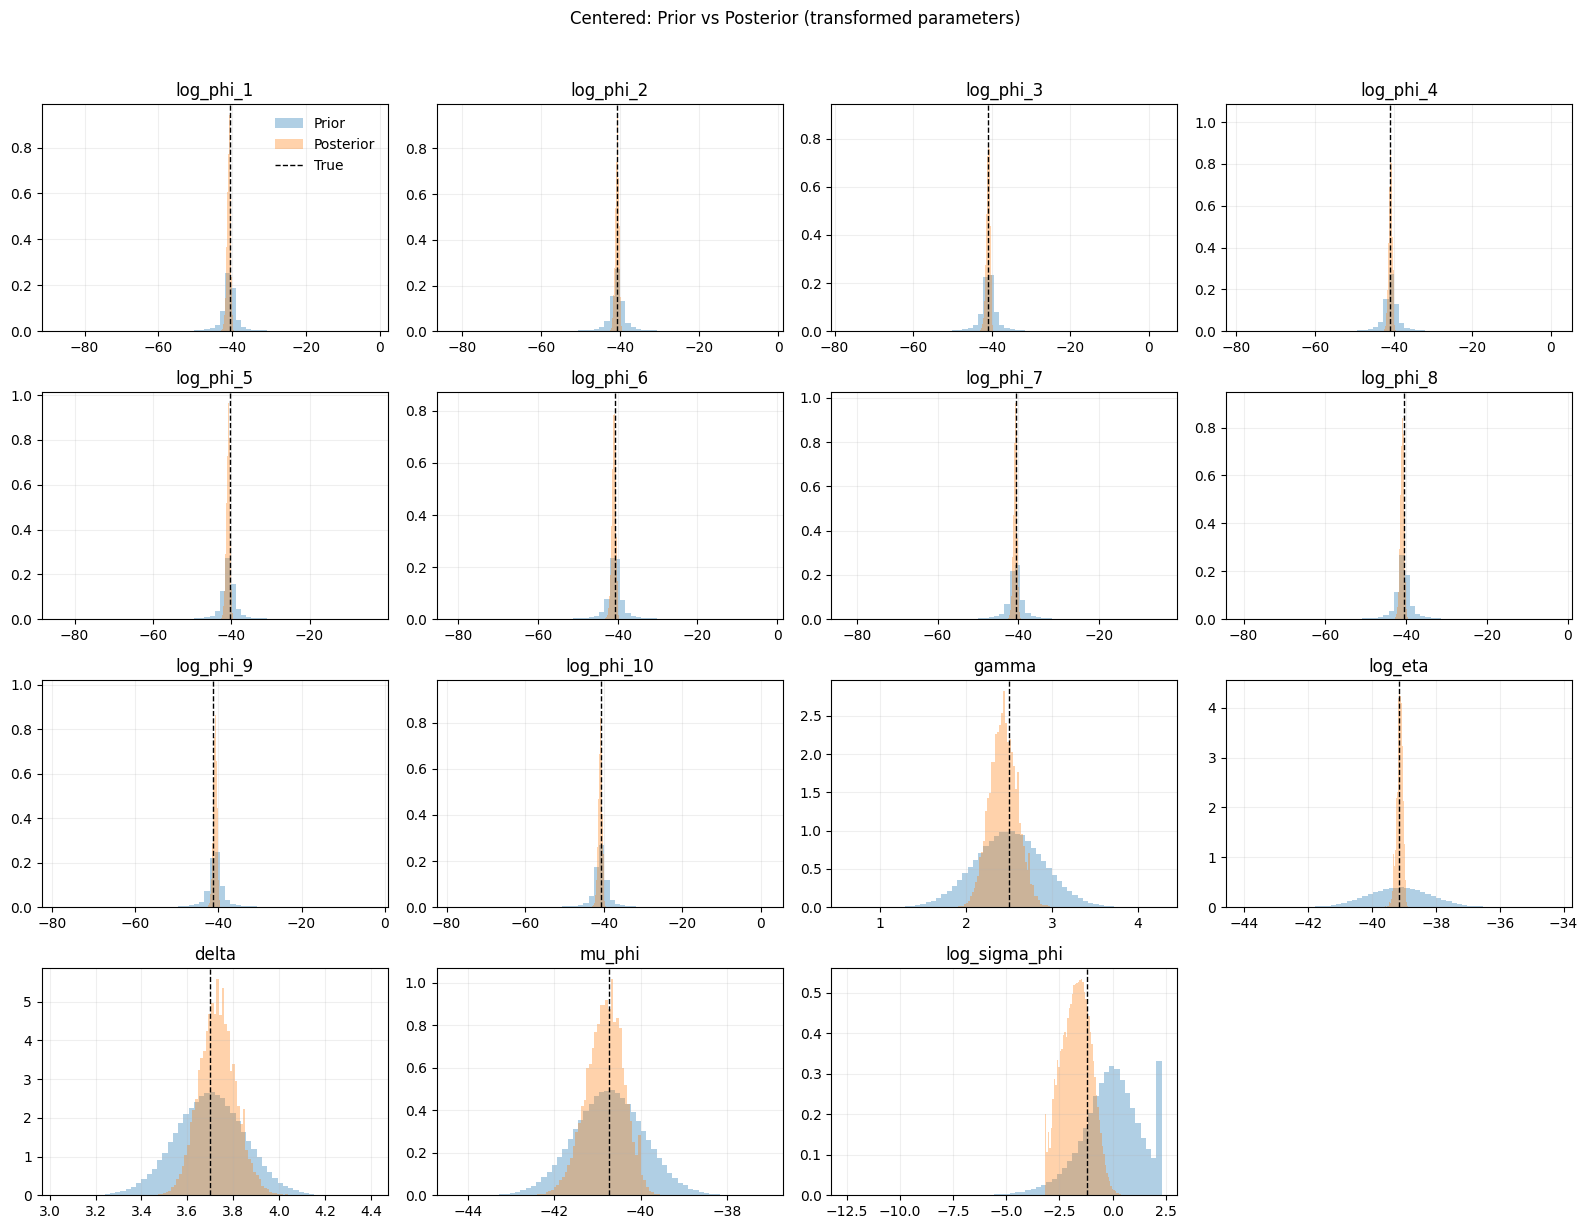

In [13]:
# Prior vs posterior plot for all transformed hierarchical parameters (MALA posterior)
posterior = np.concatenate([r.samples for r in mala_results], axis=0)

n_prior = max(20000, posterior.shape[0])
prior = np.zeros((n_prior, K + 5))

# Hyperpriors
mu_phi_prior = rng.normal(float(config["priors"]["physics"]["phi_log_mean"]), float(config["priors"]["physics"]["phi_log_sd"]), size=n_prior)
sigma_phi_prior = np.abs(rng.standard_cauchy(size=n_prior))
sigma_phi_prior = np.clip(sigma_phi_prior, 1e-6, 10.0)

log_phi_prior = mu_phi_prior[:, None] + sigma_phi_prior[:, None] * rng.normal(size=(n_prior, K))
prior[:, :K] = log_phi_prior

# Shared priors from config/defaults
prior[:, K] = rng.normal(float(phys_prior_cfg["gamma_mean"]), float(phys_prior_cfg["gamma_sd"]), size=n_prior)  # gamma
prior[:, K + 1] = rng.normal(float(phys_prior_cfg["eta_log_mean"]), float(phys_prior_cfg["eta_log_sd"]), size=n_prior)  # log_eta
prior[:, K + 2] = rng.normal(float(phys_prior_cfg["delta_mean"]), float(phys_prior_cfg["delta_sd"]), size=n_prior)  # delta
prior[:, K + 3] = mu_phi_prior
prior[:, K + 4] = np.log(sigma_phi_prior)

n_params = len(param_names)
n_cols = 4
n_rows = int(np.ceil(n_params / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(-1)

for j, name in enumerate(param_names):
    ax = axes[j]
    ax.hist(prior[:, j], bins=60, density=True, alpha=0.35, label="Prior")
    ax.hist(posterior[:, j], bins=60, density=True, alpha=0.35, label="Posterior")
    ax.axvline(theta_true[j], color="k", linestyle="--", linewidth=1.0, label="True" if j == 0 else None)
    ax.set_title(name)
    ax.grid(alpha=0.2)


for j in range(n_params, len(axes)):
    axes[j].axis("off")

axes[0].legend(frameon=False)
fig.suptitle("Centered: Prior vs Posterior (transformed parameters)", y=1.02)
fig.tight_layout()
plt.show()
